In [6]:
# RFM Analysis

This notebook builds an RFM table from the customer-level feature dataset, scores each customer, classifies them into business segments, and visualizes the result.

## Workflow
- Load the ML-ready customer dataset
- Create the RFM table
- Generate RFM scores
- Classify customers into segment labels
- Visualize the distribution of RFM segments
- Save the final dataset for downstream ML and dashboard work

SyntaxError: invalid syntax (3459069360.py, line 3)

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [8]:
# Load the customer-level feature table created in the previous notebook
customer_data = pd.read_csv('../dataset/customer_behavior.csv')

customer_data.head()

,customer_id,total_spent,avg_order_value,total_orders,total_quantity,product_variety,category_variety,avg_discount,return_count,purchase_frequency,recency,return_rate
0,C16655,13885.10,1388.510000,10,19,10,7,0.030000,0,0.016420,62,0.0
1,C13565,11984.28,2396.856000,5,10,5,3,0.060000,0,0.009653,54,0.0
2,C15379,11375.58,3791.860000,3,7,3,3,0.066667,0,0.012097,27,0.0
3,C17116,7424.34,1484.868000,5,14,5,4,0.020000,0,0.019084,455,0.0
4,C15644,7244.07,1034.867143,7,20,7,4,0.064286,0,0.012389,101,0.0


In [9]:
## What RFM Means

- **Recency**: how long ago the customer last purchased
- **Frequency**: how often the customer buys
- **Monetary**: how much the customer spendsi

Customers with a recent purchase, frequent activity, and high spending are usually the most valuable customers.

SyntaxError: invalid syntax (56815611.py, line 3)

In [10]:
# Create the core RFM table
rfm = customer_data[["customer_id", "recency", "total_orders", "total_spent"]].copy()
rfm = rfm.rename(columns={
    "total_orders": "frequency",
    "total_spent": "monetary",
})

rfm.head()

,customer_id,recency,frequency,monetary
0,C16655,62,10,13885.10
1,C13565,54,5,11984.28
2,C15379,27,3,11375.58
3,C17116,455,5,7424.34
4,C15644,101,7,7244.07


In [13]:
# Score customers by splitting each metric into quintiles
rfm["r_score"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["rfm_score"] = rfm[["r_score", "f_score", "m_score"]].sum(axis=1)

rfm.head()


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,C16655,62,10,13885.10,4,5,5,14
1,C13565,54,5,11984.28,4,3,5,12
2,C15379,27,3,11375.58,5,1,5,11
3,C17116,455,5,7424.34,1,3,5,9
4,C15644,101,7,7244.07,3,5,5,13


In [14]:
# Classify customers into simple business segments
def classify_customer(row):
    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Elite Customers"
    if row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Premium Customers"
    if row["r_score"] >= 4 and row["f_score"] >= 3:
        return "Loyal Customers"
    if row["r_score"] >= 3 and row["f_score"] >= 2:
        return "Potential Loyalists"
    if row["r_score"] <= 2 and row["f_score"] >= 3:
        return "At Risk"
    if row["r_score"] <= 2 and row["f_score"] <= 2:
        return "Lost Customers"
    return "Regular Customers"

rfm["customer_segment"] = rfm.apply(classify_customer, axis=1)

rfm[["customer_id", "recency", "frequency", "monetary", "r_score", "f_score", "m_score", "rfm_score", "customer_segment"]].head()


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,C16655,62,10,13885.10,4,5,5,14,Elite Customers
1,C13565,54,5,11984.28,4,3,5,12,Loyal Customers
2,C15379,27,3,11375.58,5,1,5,11,Regular Customers
3,C17116,455,5,7424.34,1,3,5,9,At Risk
4,C15644,101,7,7244.07,3,5,5,13,Premium Customers


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_11000\885931525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y="customer_segment", order=order, palette="viridis")


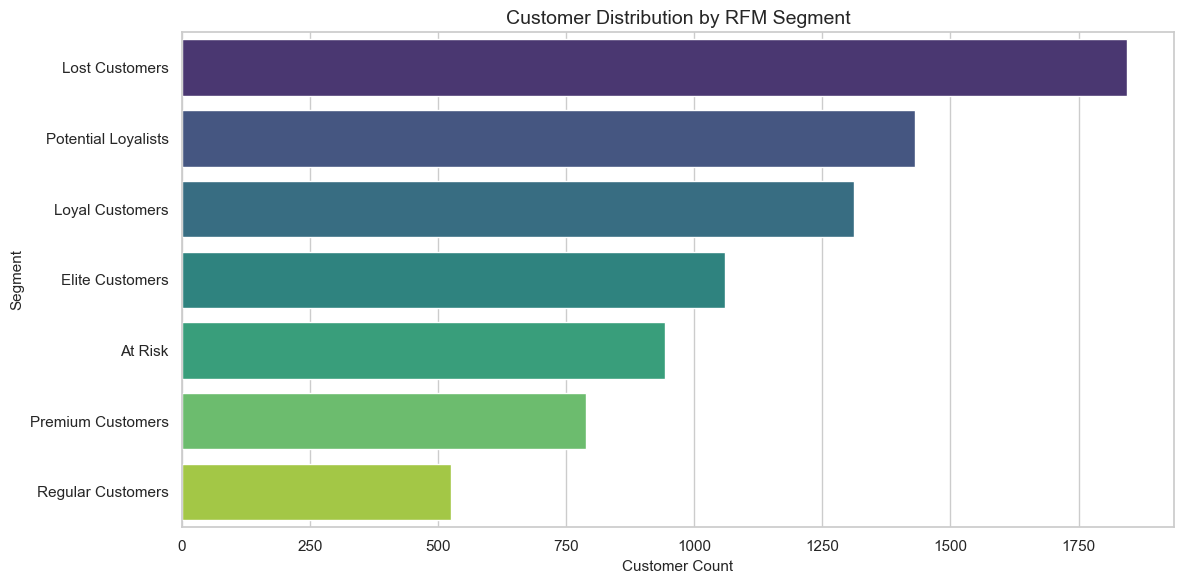

In [15]:
# Visualize the segment distribution
plt.figure(figsize=(12, 6))
order = rfm["customer_segment"].value_counts().index
sns.countplot(data=rfm, y="customer_segment", order=order, palette="viridis")
plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Count")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

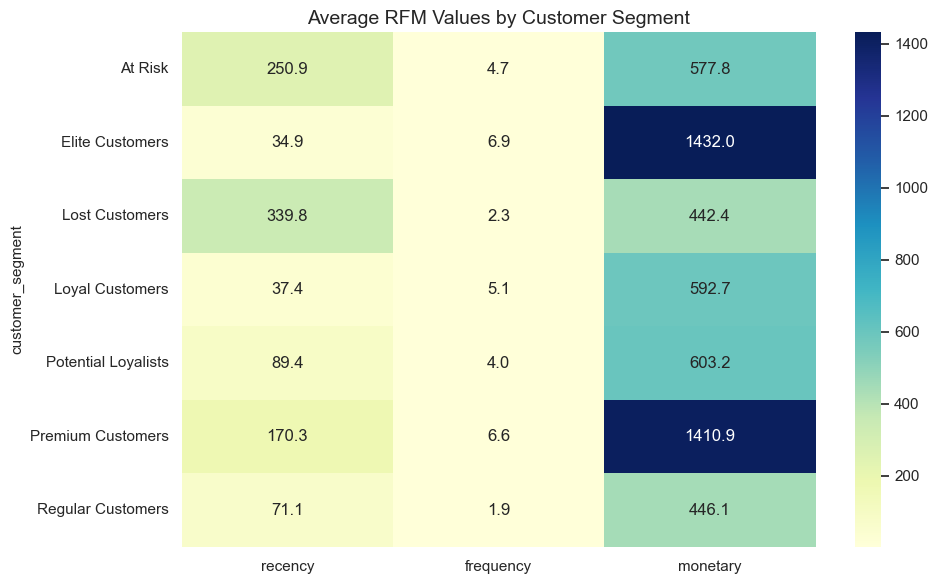

In [16]:
# Heatmap of average RFM values per segment
rfm_heatmap = rfm.groupby("customer_segment")[["recency", "frequency", "monetary"]].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(rfm_heatmap, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average RFM Values by Customer Segment")
plt.tight_layout()
plt.show()

In [17]:
# Save the final RFM dataset for the next ML stages
import os
os.makedirs('../dataset', exist_ok=True)
rfm_customer_data = rfm.sort_values(["rfm_score", "monetary"], ascending=[False, False]).reset_index(drop=True)
out_path = '../dataset/rfm_analysis.csv'
rfm_customer_data.to_csv(out_path, index=False)
print('Saved:', out_path)

rfm_customer_data.head()

Saved: ../dataset/rfm_analysis.csv


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,C10545,10,10,6238.82,5,5,5,15,Elite Customers
1,C10954,27,10,6161.11,5,5,5,15,Elite Customers
2,C11781,19,7,5635.55,5,5,5,15,Elite Customers
3,C15752,11,8,5011.05,5,5,5,15,Elite Customers
4,C13414,0,9,4947.89,5,5,5,15,Elite Customers
